# Load QM9 Dataset

In [ ]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

class CachedQM9(QM9):
    @property
    def raw_file_names(self):
        return ["qm9_v3.pt"]

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data" / "QM9"

dataset = CachedQM9(DATA_ROOT)

# Define MLP, Loss, and Training Loop

In [ ]:
import torch
from torch import nn

class DummyModel(nn.Module):
    def __init__(self, num_nodes: int, num_atom_types: int = 0):
        super().__init__()
        num_positions = 3
        # Add atom type as target if necessary
        num_targets = num_positions + num_atom_types
        self.layer = nn.Linear(
            num_nodes * num_targets, num_nodes * num_targets
        )

    def forward(self, noise: torch.Tensor):
        return self.layer(noise)

In [4]:
def compute_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)
    return v_pos - v_neg

In [ ]:

def sample_pos_noise(n_gen_mols: int, num_nodes: int):
    """Sample and center position noise for"""
    pos_noise = torch.randn((n_gen_mols * num_nodes, 3))
    batch_vec = torch.arange(n_gen_mols).repeat_interleave(num_nodes)
    pos_noise = center_positions_per_mol(pos_noise, batch_vec)
    pos_noise = pos_noise / pos_noise.std(dim=0)
    return pos_noise


def sample_type_noise(n_gen_mols: int, num_nodes: int, num_atom_types: int):
    """Sample random noise as embedding for atom types"""
    type_noise = torch.randn((n_gen_mols * num_nodes, num_atom_types))
    return type_noise


def train(
    model: DummyModel,
    optimizer: torch.optim.Optimizer,
    num_iters: int,
    n_gen_mols: int,
    num_nodes: int,
):
    loss_list = []
    for iter in range(num_iters):
        optimizer.zero_grad()

        # Sample noise once but for multiple molecules
        # as the real molecules
        noise = sample_pos_noise(n_gen_mols, num_nodes)
        noise = noise.view(n_gen_mols, -1)

        # Perform forward pass
        gen_mol = model(noise)

        # Compute loss
        V = compute_drifting_field(gen_mol, real_pos.unsqueeze(0))
        gen_mol_drifted = (gen_mol + V).detach()
        loss = F.mse_loss(gen_mol_drifted, gen_mol)

        # Perform backward pass
        loss.backward()
        optimizer.step()

        # Logging
        loss_list.append(loss.mean().item())
        if (iter + 1) % 500 == 0:
            print(f"Iter {iter}: Loss = {loss.mean().item()}")

    return loss_list, model


# Ops/Geom Aux Fns

In [46]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

# Viz Aux Fns

In [7]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_mol: torch.Tensor, real_mol: torch.Tensor):
    gen_mol = gen_mol.view(-1, 3).detach().cpu().numpy()
    real_mol = real_mol.view(-1, 3).detach().cpu().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(gen_mol[:, 0], gen_mol[:, 1], gen_mol[:, 2], color='red', label='Generated Molecule')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(real_mol[:, 0], real_mol[:, 1], real_mol[:, 2], color='blue', label='Real Molecule')
    ax2.set_title('Real Molecule')
    ax2.legend()
    plt.show()

def visualize_both_molecules_with_atom_types(gen_pos: torch.Tensor, gen_types: torch.Tensor, real_pos: torch.Tensor, real_types: torch.Tensor):
    gen_pos = gen_pos.view(-1, 3).detach().cpu().numpy()
    real_pos = real_pos.view(-1, 3).detach().cpu().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    gen_types = torch.round(gen_types, decimals=0)
    for atom_type in torch.unique(gen_types):
        mask = gen_types == atom_type
        ax1.scatter(gen_pos[mask, 0], gen_pos[mask, 1], gen_pos[mask, 2], label=f'Atom Type {atom_type.item()}')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    for atom_type in torch.unique(real_types):
        mask = real_types == atom_type
        ax2.scatter(real_pos[mask, 0], real_pos[mask, 1], real_pos[mask, 2], label=f'Atom Type {atom_type.item()}')
    ax2.set_title('Real Molecule')
    ax2.legend()
    plt.show()

def plot_loss(loss_list):
    plt.plot(loss_list)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# Sample Single Noise ONCE

We don't really care about centering because it is only one mol and one noise sample

Number of nodes: 5
Iter 99: Loss = 0.40224596858024597
Iter 199: Loss = 0.3025169372558594
Iter 299: Loss = 0.22751373052597046
Iter 399: Loss = 0.17110615968704224
Iter 499: Loss = 0.12868371605873108
Iter 599: Loss = 0.09677913784980774
Iter 699: Loss = 0.07278464734554291
Iter 799: Loss = 0.0547390840947628
Iter 899: Loss = 0.04116759076714516
Iter 999: Loss = 0.030960865318775177
Iter 1099: Loss = 0.023284729570150375
Iter 1199: Loss = 0.017511731013655663
Iter 1299: Loss = 0.013170032761991024
Iter 1399: Loss = 0.009904791601002216
Iter 1499: Loss = 0.007449097465723753
Iter 1599: Loss = 0.005602233111858368
Iter 1699: Loss = 0.004213263280689716
Iter 1799: Loss = 0.003168670926243067
Iter 1899: Loss = 0.002383063081651926
Iter 1999: Loss = 0.001792223658412695


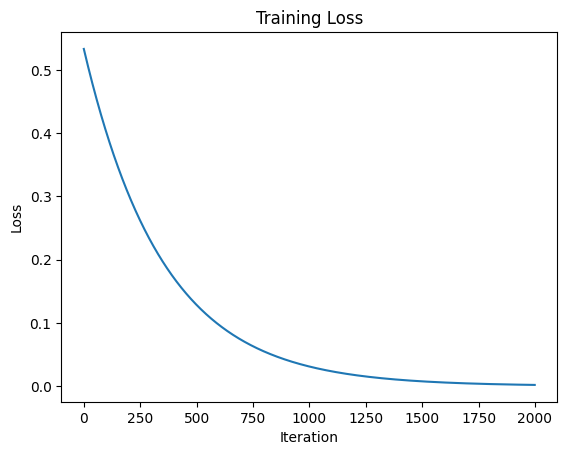

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 2000
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos.flatten()

# Sample noise once with the same shape
# as the real molecules
noise = torch.randn_like(real_mol.pos).flatten()

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(noise)
    V = real_pos - gen_mol
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

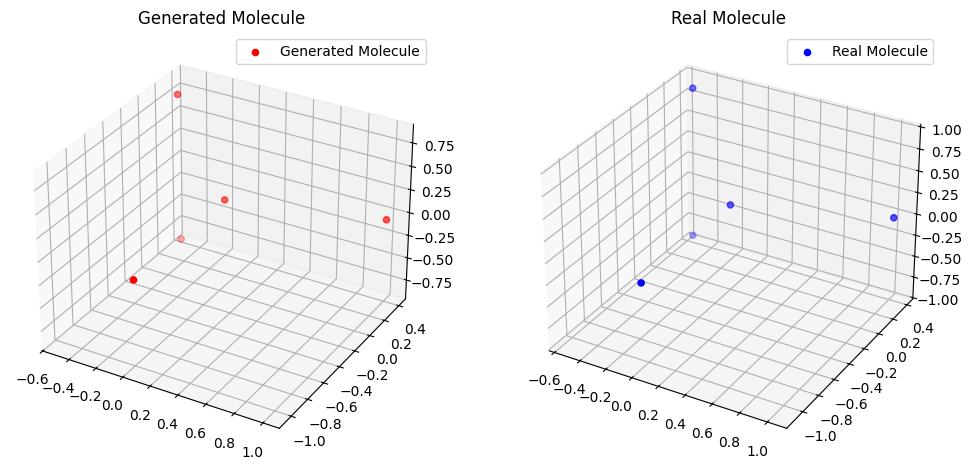

In [ ]:
visualize_both_molecules(gen_mol, real_pos)

# Sample Multiple Noise ONCE

Number of nodes: 5
Center of mass of real molecule positions: tensor([0., 0., 0.])
Std of real molecule positions: tensor([1.0000, 1.0000, 1.0000])
Center of mass of noise: tensor([ 5.1409e-09,  3.9581e-11, -1.7881e-08])
Std of noise: tensor([1.0000, 1.0000, 1.0000])

Iter 499: Loss = 0.28145280480384827
Iter 999: Loss = 0.09717267006635666
Iter 1499: Loss = 0.04417749494314194
Iter 1999: Loss = 0.025161700323224068
Iter 2499: Loss = 0.01648928038775921
Iter 2999: Loss = 0.011644795536994934
Iter 3499: Loss = 0.008565734140574932
Iter 3999: Loss = 0.006465767044574022
Iter 4499: Loss = 0.004976531490683556
Iter 4999: Loss = 0.003893888322636485
Iter 5499: Loss = 0.003092003520578146
Iter 5999: Loss = 0.0024885586462914944
Iter 6499: Loss = 0.002027867129072547
Iter 6999: Loss = 0.0016714290250092745
Iter 7499: Loss = 0.0013921801000833511
Iter 7999: Loss = 0.001170830219052732
Iter 8499: Loss = 0.0009934401605278254
Iter 8999: Loss = 0.0008498221868649125
Iter 9499: Loss = 0.0007324308

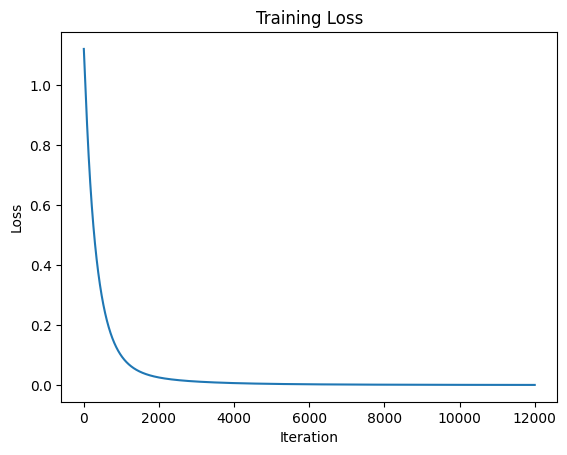

In [ ]:
import torch
import torch.nn.functional as F


NUM_ITERS = 12000
N_GEN_MOLS = 10
LR = 0.005

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Center of mass of real molecule positions: {real_pos.mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")
real_pos = real_pos.flatten()


# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once but for multiple molecules
# as the real molecules
# This is the logic in sample noise above
# We keep this here to be explicit about debugging prints
noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3))
batch_vec = torch.arange(N_GEN_MOLS).repeat_interleave(real_mol.num_nodes)
noise = center_positions_per_mol(noise, batch_vec)
noise = noise / noise.std(dim=0)
print(f"Center of mass of noise: {global_mean_pool(noise, batch_vec).mean(dim=0)}")
print(f"Std of noise: {noise.std(dim=0)}")
print()
noise = noise.view(N_GEN_MOLS, -1)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(noise)
    V = compute_drifting_field(gen_mol, real_pos.unsqueeze(0))
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 500 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

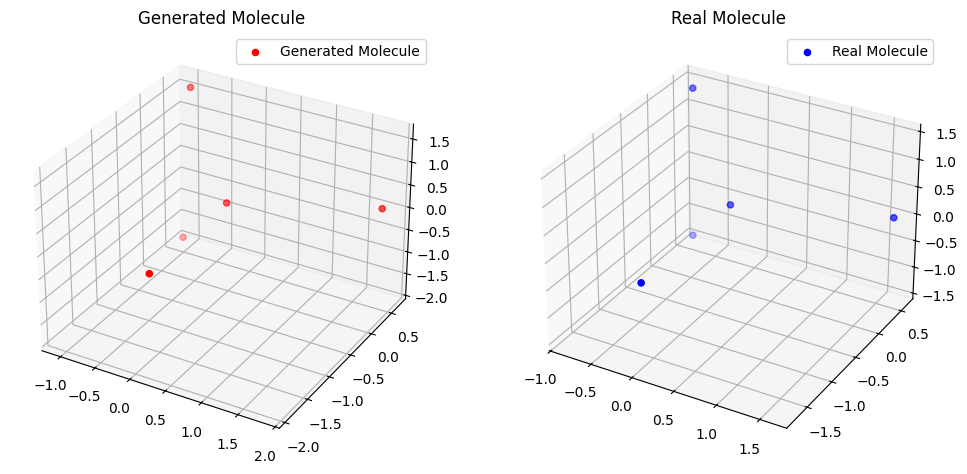

In [ ]:
sorted_mols, _ = get_sorted_mols(gen_mol, real_pos.unsqueeze(0))
visualize_both_molecules(sorted_mols[9].view(-1, 3), real_pos.view(-1, 3))

# Sample DIFFERENT noise every time

Number of nodes: 5
Iter 499: Loss = 1.0157642364501953
Iter 999: Loss = 0.9831550121307373
Iter 1499: Loss = 0.7706218361854553
Iter 1999: Loss = 0.6246938109397888
Iter 2499: Loss = 0.5060461163520813
Iter 2999: Loss = 0.42866250872612
Iter 3499: Loss = 0.3743332028388977
Iter 3999: Loss = 0.36626681685447693
Iter 4499: Loss = 0.2866996228694916
Iter 4999: Loss = 0.2729075849056244
Iter 5499: Loss = 0.2685152590274811
Iter 5999: Loss = 0.1858794093132019
Iter 6499: Loss = 0.17868980765342712
Iter 6999: Loss = 0.19099105894565582
Iter 7499: Loss = 0.13358688354492188
Iter 7999: Loss = 0.11979545652866364
Iter 8499: Loss = 0.12159059196710587
Iter 8999: Loss = 0.08302221447229385
Iter 9499: Loss = 0.07051222771406174
Iter 9999: Loss = 0.07324952632188797
Iter 10499: Loss = 0.05655067414045334
Iter 10999: Loss = 0.036108896136283875
Iter 11499: Loss = 0.0649903193116188
Iter 11999: Loss = 0.04492269083857536
Iter 12499: Loss = 0.04000759869813919
Iter 12999: Loss = 0.024394750595092773
I

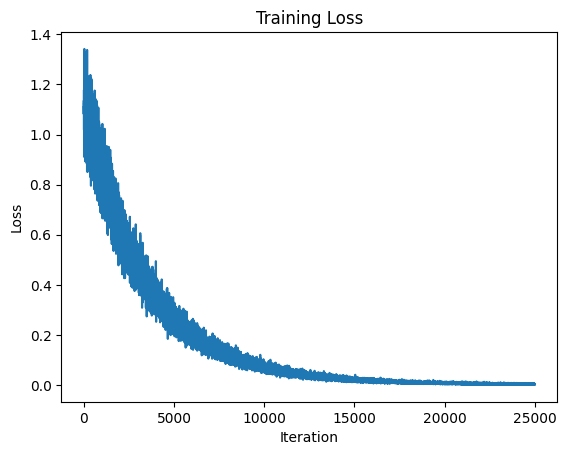

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 25000
N_GEN_MOLS = 10
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.flatten()

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Train model
loss_list, model = train(
    model,
    optimizer,
    NUM_ITERS,
    N_GEN_MOLS,
    num_nodes=real_mol.num_nodes
)

plot_loss(loss_list)

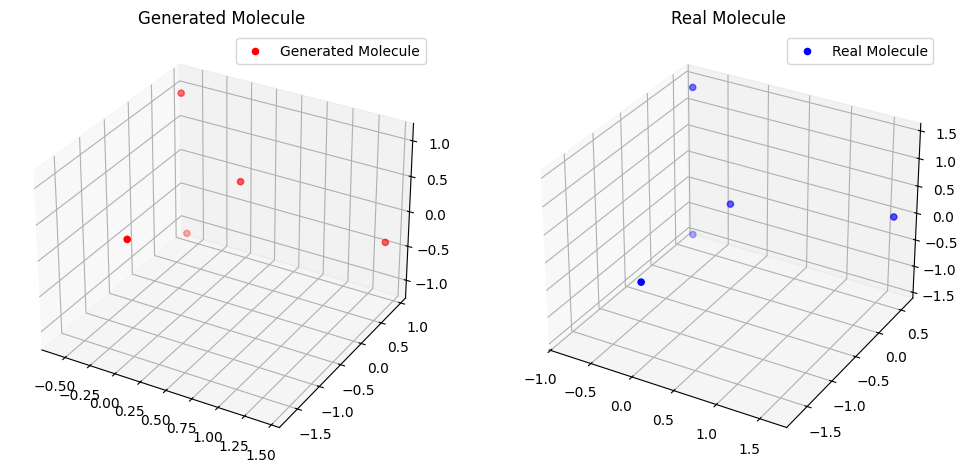

In [ ]:
noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
noise = noise.view(N_GEN_MOLS, -1)
gen_mol = model(noise)

sorted_mols, _ = get_sorted_mols(gen_mol.view(-1, 3), real_pos.view(-1, 3))
visualize_both_molecules(sorted_mols[9], real_pos)

# One Gen Mol and One Real Mol WITH Atom Types

Number of nodes: 5
Real molecule positions shape: torch.Size([5, 3])
Real molecule atom types shape: torch.Size([5, 5])
Combined real molecule shape: torch.Size([40])
Position noise shape: torch.Size([5, 3])
Combined noise shape: torch.Size([40])

Iter 99: Loss = 0.5600471496582031
Iter 199: Loss = 0.4228397011756897
Iter 299: Loss = 0.3192470669746399
Iter 399: Loss = 0.24103383719921112
Iter 499: Loss = 0.18198230862617493
Iter 599: Loss = 0.13739798963069916
Iter 699: Loss = 0.1037365049123764
Iter 799: Loss = 0.07832182198762894
Iter 899: Loss = 0.05913354828953743
Iter 999: Loss = 0.044646255671978
Iter 1099: Loss = 0.03370827063918114
Iter 1199: Loss = 0.025449994951486588
Iter 1299: Loss = 0.019214939326047897
Iter 1399: Loss = 0.014507418498396873
Iter 1499: Loss = 0.010953198187053204
Iter 1599: Loss = 0.008269750513136387
Iter 1699: Loss = 0.006243717856705189
Iter 1799: Loss = 0.004714058246463537
Iter 1899: Loss = 0.0035591486375778913
Iter 1999: Loss = 0.002687184605747461

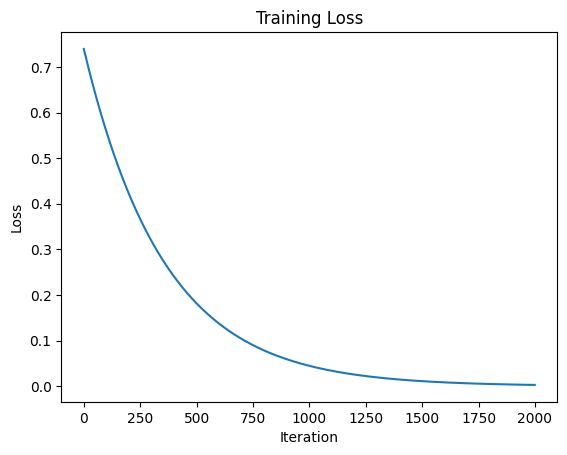

In [72]:
import torch
import torch.nn.functional as F

NUM_ITERS = 2000
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Real molecule positions shape: {real_pos.shape}")

real_types = real_mol.real_atom_types
print(f"Real molecule atom types shape: {real_types.shape}")
real_mol_combined = torch.cat([real_pos, real_types], dim=1)
real_mol_combined = real_mol_combined.flatten()
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once but for multiple molecules
# as the real molecules
# This is the logic in sample noise above
pos_noise = torch.randn((real_mol.num_nodes, 3))
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
print(f"Position noise shape: {pos_noise.shape}")

# We sample random noise as embedding for atom types
type_noise = torch.randn((real_mol.num_nodes, NUM_ATOM_TYPES))
combined_noise = torch.cat([pos_noise, type_noise], dim=1).flatten()
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(combined_noise)
    V = real_mol_combined - gen_mol
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Generated atom types (rounded): 
 tensor([[-0., 1., 0., 0., -0.],
        [1., -0., -0., -0., 0.],
        [1., -0., -0., -0., 0.],
        [1., -0., 0., 0., 0.],
        [1., -0., 0., 0., -0.]], grad_fn=<RoundBackward0>)
torch.Size([5])


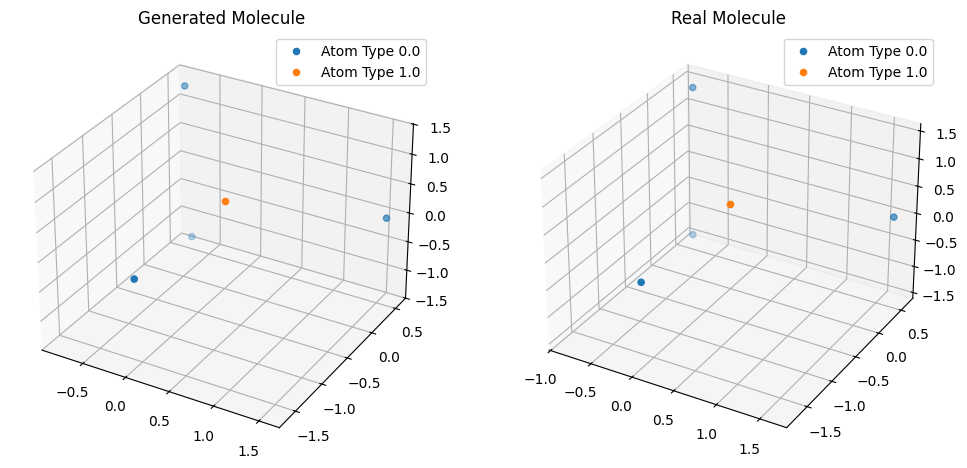

In [74]:
gen_pos, gen_types = gen_mol.view(
    real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Generated atom types (rounded): \n {gen_types.round()}")

gen_types_argmax = gen_types.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

print(real_types_argmax.shape)

visualize_both_molecules_with_atom_types(
    gen_pos, gen_types_argmax, real_pos, real_types_argmax
)

# Atom Types + Pos | Multiple Noise and One Mol

Overfitting is possible with enough training time. Repulsion should not be a problem here.

Number of nodes: 5
Combined real molecule shape: torch.Size([40])
Position noise shape: torch.Size([50, 3])
Type noise shape: torch.Size([50, 5])
Combined noise shape: torch.Size([10, 40])

Iter 99: Loss = 0.5948534607887268
Iter 199: Loss = 0.5565013289451599
Iter 299: Loss = 0.5205962657928467
Iter 399: Loss = 0.48696067929267883
Iter 499: Loss = 0.4554285407066345
Iter 599: Loss = 0.42584601044654846
Iter 699: Loss = 0.3980737030506134
Iter 799: Loss = 0.37198635935783386
Iter 899: Loss = 0.3474729061126709
Iter 999: Loss = 0.3244354724884033
Iter 1099: Loss = 0.3027886152267456
Iter 1199: Loss = 0.2824574410915375
Iter 1299: Loss = 0.26337602734565735
Iter 1399: Loss = 0.24548529088497162
Iter 1499: Loss = 0.228731170296669
Iter 1599: Loss = 0.2130628526210785
Iter 1699: Loss = 0.19843131303787231
Iter 1799: Loss = 0.18478824198246002
Iter 1899: Loss = 0.17208534479141235
Iter 1999: Loss = 0.16027390956878662
Iter 2099: Loss = 0.14930495619773865
Iter 2199: Loss = 0.139129251241683

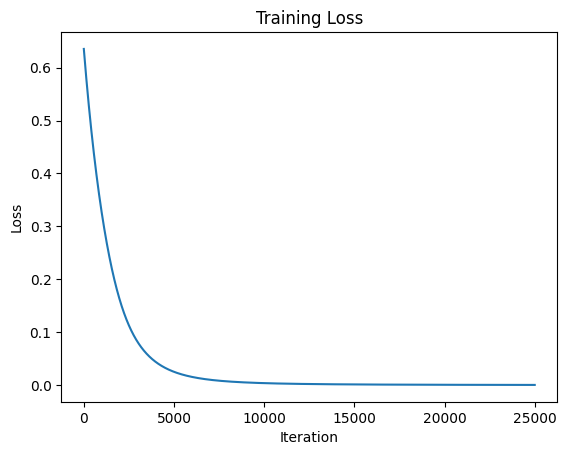

In [78]:
import torch
import torch.nn.functional as F

NUM_ITERS = 25000
N_GEN_MOLS = 10
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.view(1, -1)

real_types = real_mol.real_atom_types.view(1, -1)
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
type_noise = sample_type_noise(N_GEN_MOLS, real_mol.num_nodes, NUM_ATOM_TYPES)
print(f"Position noise shape: {pos_noise.shape}")
print(f"Type noise shape: {type_noise.shape}")
combined_noise = torch.cat([pos_noise, type_noise], dim=1)
combined_noise = combined_noise.view(N_GEN_MOLS, -1)
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * real_mol.num_nodes, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 1.0


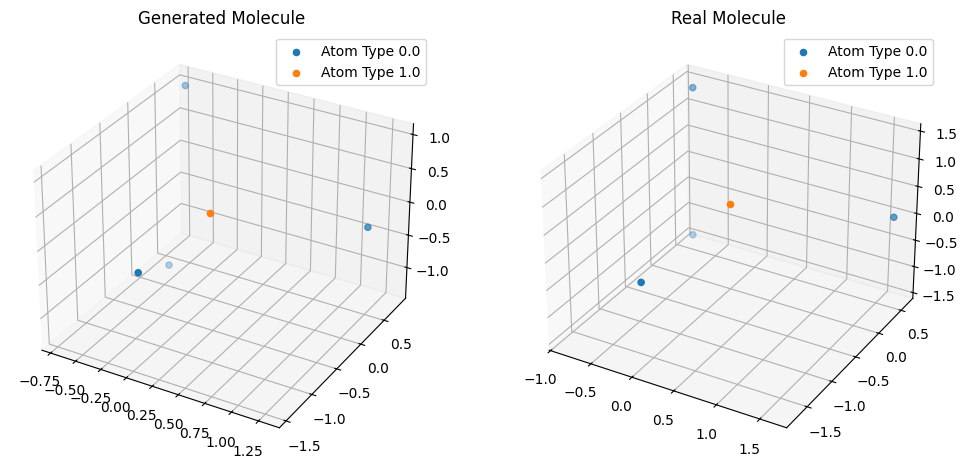

In [ ]:
gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), real_pos
)

SELECTED_IDX = 9

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, real_pos.view(-1, 3), real_types_argmax
)

# Pos + Types | Different Noise Every Time

Number of nodes: 5
Combined real molecule shape: torch.Size([40])
Iter 99: Loss = 0.7120481729507446
Iter 199: Loss = 0.6479562520980835
Iter 299: Loss = 0.617200493812561
Iter 399: Loss = 0.6756860613822937
Iter 499: Loss = 0.6873117685317993
Iter 599: Loss = 0.686601996421814
Iter 699: Loss = 0.8294133543968201
Iter 799: Loss = 0.7824108004570007
Iter 899: Loss = 0.6966568231582642
Iter 999: Loss = 0.6402565240859985
Iter 1099: Loss = 0.7394413948059082
Iter 1199: Loss = 0.625499963760376
Iter 1299: Loss = 0.6306924819946289
Iter 1399: Loss = 0.5787439942359924
Iter 1499: Loss = 0.6077677607536316
Iter 1599: Loss = 0.6584140062332153
Iter 1699: Loss = 0.6161024570465088
Iter 1799: Loss = 0.632632851600647
Iter 1899: Loss = 0.6448901295661926
Iter 1999: Loss = 0.6501623392105103
Iter 2099: Loss = 0.5643665194511414
Iter 2199: Loss = 0.5894235968589783
Iter 2299: Loss = 0.5763906836509705
Iter 2399: Loss = 0.6329619884490967
Iter 2499: Loss = 0.5467102527618408
Iter 2599: Loss = 0.6014

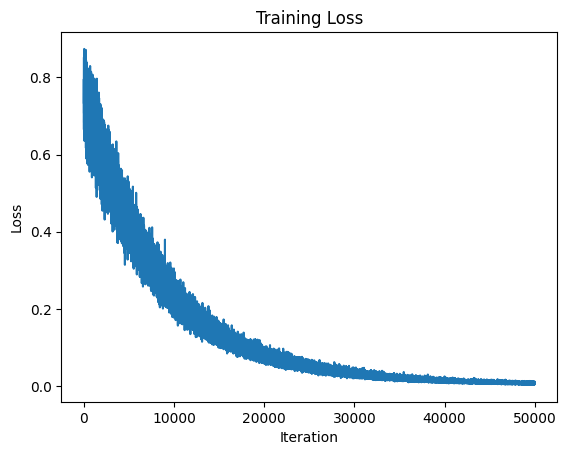

In [ ]:
import torch
import torch.nn.functional as F

NUM_ITERS = 50000
N_GEN_MOLS = 10
NUM_ATOM_TYPES = 5
LR = 0.001

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.view(1, -1)
real_types = real_mol.real_atom_types.view(1, -1)

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=real_mol.num_nodes, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise as before
    pos_noise = sample_pos_noise(N_GEN_MOLS, real_mol.num_nodes)
    type_noise = sample_type_noise(N_GEN_MOLS, real_mol.num_nodes, NUM_ATOM_TYPES)
    combined_noise = torch.cat([pos_noise, type_noise], dim=1)
    combined_noise = combined_noise.view(N_GEN_MOLS, -1)


    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * real_mol.num_nodes, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 1.0


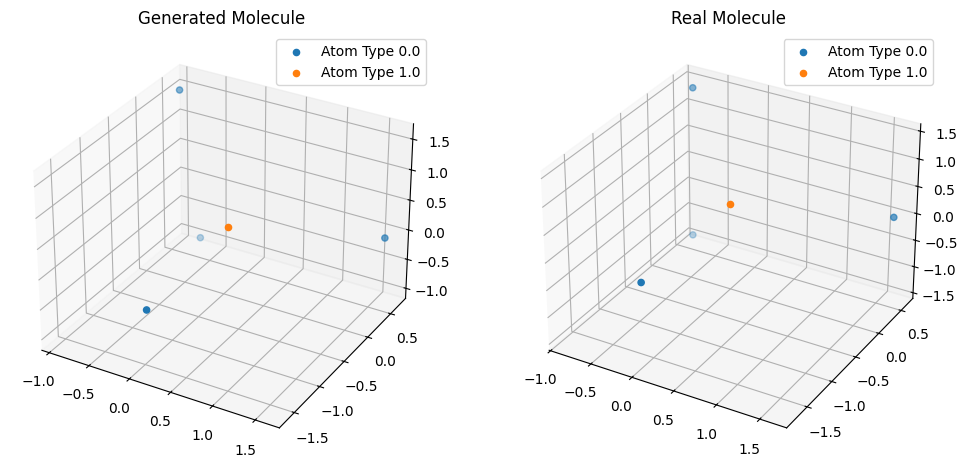

In [ ]:
gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * real_mol.num_nodes, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), real_pos
)

SELECTED_IDX = 0

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, real_pos.view(-1, 3), real_types_argmax
)

# Multiple Real Molecules with Same Number of atoms

Center of mass of real molecule positions: tensor([5.9605e-09, 2.3842e-08, 2.3842e-08])
Std of real molecule positions: tensor([1., 1., 1.])

Iter 99: Loss = 0.5367621183395386
Iter 199: Loss = 0.4646275043487549
Iter 299: Loss = 0.5086796283721924
Iter 399: Loss = 0.5088953375816345
Iter 499: Loss = 0.48539212346076965
Iter 599: Loss = 0.47407007217407227
Iter 699: Loss = 0.48679766058921814
Iter 799: Loss = 0.47280973196029663
Iter 899: Loss = 0.4719422459602356
Iter 999: Loss = 0.46364739537239075
Iter 1099: Loss = 0.4692598283290863
Iter 1199: Loss = 0.4633884131908417
Iter 1299: Loss = 0.43754392862319946
Iter 1399: Loss = 0.45183300971984863
Iter 1499: Loss = 0.42378291487693787
Iter 1599: Loss = 0.4179029166698456
Iter 1699: Loss = 0.4203188419342041
Iter 1799: Loss = 0.4048166573047638
Iter 1899: Loss = 0.4132544994354248
Iter 1999: Loss = 0.40372470021247864
Iter 2099: Loss = 0.3879316747188568
Iter 2199: Loss = 0.3918752372264862
Iter 2299: Loss = 0.38241854310035706
Iter 239

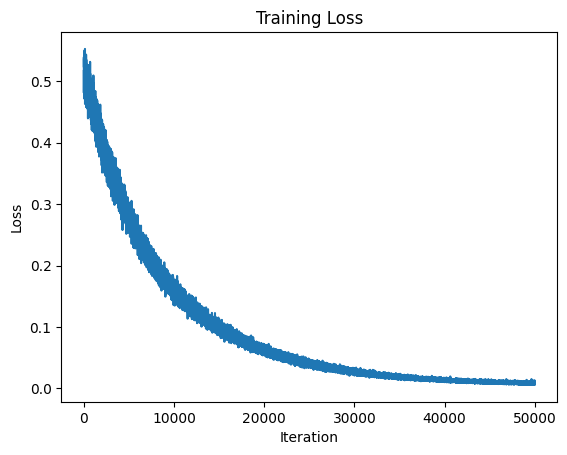

In [139]:
import torch
import torch.nn.functional as F

NUM_ITERS = 50000
N_GEN_MOLS = 100
N_REAL_MOLS = 2
NUM_ATOM_TYPES = 5
NUM_ATOMS = 5
LR = 0.001

keep = []
for i, d in enumerate(dataset):
    if d.num_nodes == NUM_ATOMS:
        keep.append(i)
    if len(keep) >= N_REAL_MOLS:
        break
filtered_dataset = dataset.index_select(keep)

batch_vec = torch.arange(N_REAL_MOLS).repeat_interleave(NUM_ATOMS)
real_pos = center_positions_per_mol(
    filtered_dataset.pos, batch_vec
)
real_pos = real_pos / real_pos.std(dim=0)
print(f"Center of mass of real molecule positions: {global_mean_pool(real_pos, batch_vec).mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")
print()

real_pos = real_pos.view(N_REAL_MOLS, -1)
real_types = filtered_dataset.real_atom_types.view(N_REAL_MOLS, -1)

# Instantiate model and optimizer
model = DummyModel(
    num_nodes=NUM_ATOMS, num_atom_types=NUM_ATOM_TYPES
)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise as before
    pos_noise = sample_pos_noise(N_GEN_MOLS, NUM_ATOMS)
    type_noise = sample_type_noise(N_GEN_MOLS, NUM_ATOMS, NUM_ATOM_TYPES)
    combined_noise = torch.cat([pos_noise, type_noise], dim=1)
    combined_noise = combined_noise.view(N_GEN_MOLS, -1)


    gen_mol = model(combined_noise)

    # Reshape and split generated molecule into positions and atom types
    gen_mol_split = gen_mol.view(N_GEN_MOLS * NUM_ATOMS, -1)
    gen_pos, gen_types = gen_mol_split.split([3, NUM_ATOM_TYPES], dim=1)

    # Reshape to get right positions
    gen_pos = gen_pos.reshape(N_GEN_MOLS, -1)
    gen_types = gen_types.reshape(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos)
    V_types = compute_drifting_field(gen_types, real_types)

    V_pos = V_pos.view(N_GEN_MOLS * NUM_ATOMS, 3)
    V_types = V_types.view(N_GEN_MOLS * NUM_ATOMS, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=1)
    V_combined = V_combined.view(N_GEN_MOLS, -1)

    gen_mol_drifted = (gen_mol + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)


Mean of rounded atom types: 0.9639999866485596
Rounded viz types: 
 tensor([[ 0.,  1.,  0.,  0.,  0.],
        [ 0.,  1., -0., -0.,  0.],
        [ 0.,  1., -0., -0.,  0.],
        [ 1.,  0., -1.,  0., -0.],
        [ 0., -0.,  1.,  0., -0.]], grad_fn=<RoundBackward0>)


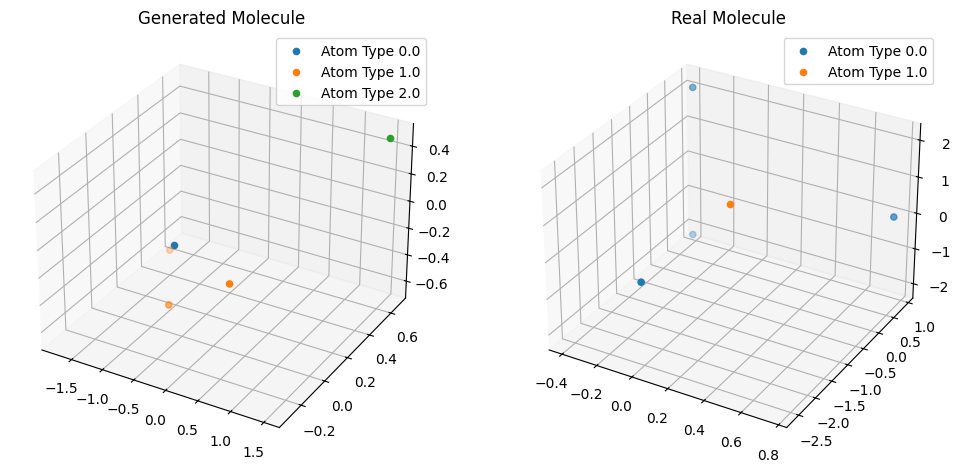

In [141]:
REAL_MOL_IDX = 0

selected_real_pos = real_pos[REAL_MOL_IDX].view(1, -1)
selected_real_types = real_types[REAL_MOL_IDX].view(1, -1)

gen_pos, gen_types = gen_mol.view(
    N_GEN_MOLS * NUM_ATOMS, -1
).split([3, NUM_ATOM_TYPES], dim=1)

print(f"Mean of rounded atom types: {gen_types.round().sum(dim=1).mean().item()}")

sorted_pos, closest_indices = get_sorted_mols(
    gen_pos.reshape(N_GEN_MOLS, -1), selected_real_pos
)

SELECTED_IDX = 0

viz_pos = sorted_pos[SELECTED_IDX].squeeze()
viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]
viz_types = viz_types.view(-1, NUM_ATOM_TYPES)
print(f"Rounded viz types: \n {viz_types.round()}")
viz_types = viz_types.argmax(dim=1).float()

real_types_argmax = selected_real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

visualize_both_molecules_with_atom_types(
    viz_pos.view(-1, 3), viz_types, selected_real_pos.view(-1, 3), real_types_argmax
)

# Bandwidth, Diversity, and Validity Sweep

This section trains the same position-plus-type drift model across kernel bandwidths, then evaluates loss, generated diversity, nearest-real distances, atom stability, molecule stability, RDKit validity, and uniqueness.

In [49]:
import sys
import time
import torch
import torch.nn.functional as F
from IPython.display import display

if "PROJECT_ROOT" in globals() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from model.mol_utils.stability import batch_to_stability
from model.mol_utils.validity import batch_to_validity


def atom_count_histogram(dataset):
    counts = {}
    for d in dataset:
        n = int(d.num_nodes)
        counts[n] = counts.get(n, 0) + 1
    return dict(sorted(counts.items()))


def choose_atom_count(dataset, required: int, preferred: int | None = None):
    counts = atom_count_histogram(dataset)
    if preferred is not None and counts.get(preferred, 0) >= required:
        print(f"Using preferred atom count {preferred} with {counts[preferred]} molecules")
        return preferred

    viable = [(n, c) for n, c in counts.items() if c >= required]
    if not viable:
        raise ValueError(f"No atom count has at least {required} molecules. Counts: {counts}")

    chosen, available = viable[0]
    if preferred is not None:
        print(
            f"Preferred atom count {preferred} only has {counts.get(preferred, 0)} molecules; "
            f"using {chosen} atoms with {available} molecules instead."
        )
    else:
        print(f"Using atom count {chosen} with {available} molecules")
    return chosen


def collect_same_size_qm9(dataset, num_atoms: int, n_train: int, n_test: int):
    keep = []
    for i, d in enumerate(dataset):
        if d.num_nodes == num_atoms:
            keep.append(i)
        if len(keep) >= n_train + n_test:
            break
    if len(keep) < n_train + n_test:
        raise ValueError(f"Only found {len(keep)} molecules with {num_atoms} atoms")

    train_data = dataset.index_select(keep[:n_train])
    test_data = dataset.index_select(keep[n_train:n_train + n_test])

    train_batch = torch.arange(n_train).repeat_interleave(num_atoms)
    test_batch = torch.arange(n_test).repeat_interleave(num_atoms)

    train_pos_centered = center_positions_per_mol(train_data.pos, train_batch)
    pos_scale = train_pos_centered.std(dim=0).clamp_min(1e-8)
    train_pos = train_pos_centered / pos_scale
    test_pos = center_positions_per_mol(test_data.pos, test_batch) / pos_scale

    return {
        "train_pos": train_pos.view(n_train, -1),
        "test_pos": test_pos.view(n_test, -1),
        "train_types": train_data.real_atom_types.view(n_train, -1),
        "test_types": test_data.real_atom_types.view(n_test, -1),
        "pos_scale": pos_scale,
    }


def sample_combined_noise(n_mols: int, num_atoms: int, num_atom_types: int):
    pos_noise = sample_pos_noise(n_mols, num_atoms)
    type_noise = sample_type_noise(n_mols, num_atoms, num_atom_types)
    return torch.cat([pos_noise, type_noise], dim=1).view(n_mols, -1)


def split_generated(gen_mol: torch.Tensor, n_mols: int, num_atoms: int, num_atom_types: int):
    flat = gen_mol.view(n_mols * num_atoms, -1)
    gen_pos, gen_types = flat.split([3, num_atom_types], dim=1)
    return gen_pos, gen_types


def generated_metrics(
    model,
    data,
    n_eval_mols: int,
    num_atoms: int,
    num_atom_types: int,
):
    model.eval()
    with torch.no_grad():
        noise = sample_combined_noise(n_eval_mols, num_atoms, num_atom_types)
        gen_mol = model(noise)
        gen_pos, gen_types = split_generated(gen_mol, n_eval_mols, num_atoms, num_atom_types)

        gen_pos_flat = gen_pos.reshape(n_eval_mols, -1)
        train_dist = torch.cdist(gen_pos_flat, data["train_pos"])
        test_dist = torch.cdist(gen_pos_flat, data["test_pos"])
        gen_dist = torch.cdist(gen_pos_flat, gen_pos_flat)
        off_diag = ~torch.eye(n_eval_mols, dtype=torch.bool)

        atom_type_idx = gen_types.argmax(dim=1).detach().cpu().long()
        batch_vec = torch.arange(n_eval_mols).repeat_interleave(num_atoms)
        pos_angstrom = (gen_pos.detach().cpu() * data["pos_scale"].cpu())

        atom_stable, mol_stable = batch_to_stability(pos_angstrom, atom_type_idx, batch_vec)
        validity = batch_to_validity(pos_angstrom, atom_type_idx, batch_vec)
        valid_ids = [identifier for is_valid, identifier in validity if is_valid and identifier]
        type_hist = torch.bincount(atom_type_idx, minlength=num_atom_types).float()
        type_hist = type_hist / type_hist.sum().clamp_min(1.0)

    return {
        "nearest_train": train_dist.min(dim=1).values.mean().item(),
        "nearest_test": test_dist.min(dim=1).values.mean().item(),
        "gen_diversity": gen_dist[off_diag].mean().item(),
        "atom_stable": atom_stable,
        "mol_stable": mol_stable,
        "valid": sum(is_valid for is_valid, _ in validity) / len(validity),
        "unique_valid": len(set(valid_ids)) / max(1, len(valid_ids)),
        "type_hist": type_hist.tolist(),
    }


def train_one_bandwidth(
    sigma: float,
    data,
    num_iters: int,
    n_gen_mols: int,
    n_eval_mols: int,
    num_atoms: int,
    num_atom_types: int,
    lr: float,
    log_every: int = 500,
):
    model = DummyModel(num_nodes=num_atoms, num_atom_types=num_atom_types)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    drift_norms = []
    start = time.time()

    for step in range(num_iters):
        optimizer.zero_grad()
        noise = sample_combined_noise(n_gen_mols, num_atoms, num_atom_types)
        gen_mol = model(noise)
        gen_pos, gen_types = split_generated(gen_mol, n_gen_mols, num_atoms, num_atom_types)

        gen_pos_flat = gen_pos.reshape(n_gen_mols, -1)
        gen_types_flat = gen_types.reshape(n_gen_mols, -1)

        V_pos = compute_drifting_field(gen_pos_flat, data["train_pos"], sigma=sigma)
        V_types = compute_drifting_field(gen_types_flat, data["train_types"], sigma=sigma)
        V_pos = V_pos.view(n_gen_mols * num_atoms, 3)
        V_types = V_types.view(n_gen_mols * num_atoms, num_atom_types)
        V_combined = torch.cat([V_pos, V_types], dim=1).view(n_gen_mols, -1)

        drift_norms.append(V_combined.norm(dim=1).mean().item())
        loss = F.mse_loss((gen_mol + V_combined).detach(), gen_mol)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        if (step + 1) % log_every == 0:
            print(f"sigma={sigma:<4} iter={step + 1:<6} loss={loss.item():.6f}")

    metrics = generated_metrics(model, data, n_eval_mols, num_atoms, num_atom_types)
    metrics.update({
        "sigma": sigma,
        "final_loss": losses[-1],
        "min_loss": min(losses),
        "final_drift": drift_norms[-1],
        "max_drift": max(drift_norms),
        "seconds": time.time() - start,
        "losses": losses,
        "drift_norms": drift_norms,
        "model": model,
    })
    return metrics


def print_sweep_table(results):
    headers = [
        "sigma", "final", "drift", "maxdrift", "div", "nn_train", "nn_test",
        "atom_st", "mol_st", "valid", "uniq", "sec",
    ]
    print(" ".join(f"{h:>9}" for h in headers))
    for r in results:
        vals = [
            r["sigma"], r["final_loss"], r["final_drift"], r["max_drift"],
            r["gen_diversity"], r["nearest_train"], r["nearest_test"], r["atom_stable"],
            r["mol_stable"], r["valid"], r["unique_valid"], r["seconds"],
        ]
        print(
            f"{vals[0]:9.3g} {vals[1]:9.4f} {vals[2]:9.4f} {vals[3]:9.4f} "
            f"{vals[4]:9.4f} {vals[5]:9.4f} {vals[6]:9.4f} {vals[7]:9.3f} "
            f"{vals[8]:9.3f} {vals[9]:9.3f} {vals[10]:9.3f} {vals[11]:9.1f}"
        )


Preferred atom count 5 only has 5 molecules; using 8 atoms with 65 molecules instead.
sigma=1.0  iter=500    loss=0.459927
sigma=1.0  iter=1000   loss=0.433819
sigma=1.0  iter=1500   loss=0.425127
sigma=1.0  iter=2000   loss=0.423243
sigma=1.0  iter=2500   loss=0.379726
sigma=1.0  iter=3000   loss=0.382337
sigma=3.0  iter=500    loss=0.129653
sigma=3.0  iter=1000   loss=0.128628
sigma=3.0  iter=1500   loss=0.131212
sigma=3.0  iter=2000   loss=0.116661
sigma=3.0  iter=2500   loss=0.113174
sigma=3.0  iter=3000   loss=0.125417
sigma=10.0 iter=500    loss=0.126851
sigma=10.0 iter=1000   loss=0.126261
sigma=10.0 iter=1500   loss=0.127660
sigma=10.0 iter=2000   loss=0.127908
sigma=10.0 iter=2500   loss=0.111754
sigma=10.0 iter=3000   loss=0.115626
sigma=30.0 iter=500    loss=0.118570
sigma=30.0 iter=1000   loss=0.105016
sigma=30.0 iter=1500   loss=0.118150
sigma=30.0 iter=2000   loss=0.105230
sigma=30.0 iter=2500   loss=0.101547
sigma=30.0 iter=3000   loss=0.110184
    sigma     final     dr

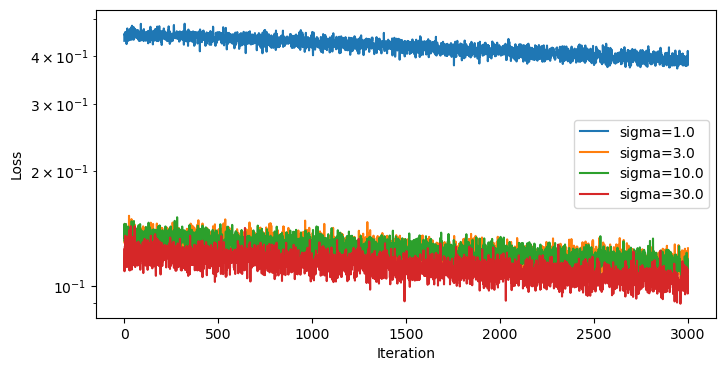

In [50]:
SWEEP_PREFERRED_NUM_ATOMS = 5
SWEEP_NUM_ATOM_TYPES = 5
SWEEP_N_REAL_TRAIN = 16
SWEEP_N_REAL_TEST = 16
SWEEP_N_GEN_MOLS = 64
SWEEP_N_EVAL_MOLS = 64
SWEEP_NUM_ITERS = 3000
SWEEP_LR = 0.001
SWEEP_SIGMAS = [1.0, 3.0, 10.0, 30.0]
SWEEP_NUM_ATOMS = choose_atom_count(
    dataset,
    required=SWEEP_N_REAL_TRAIN + SWEEP_N_REAL_TEST,
    preferred=SWEEP_PREFERRED_NUM_ATOMS,
)

sweep_data = collect_same_size_qm9(
    dataset,
    num_atoms=SWEEP_NUM_ATOMS,
    n_train=SWEEP_N_REAL_TRAIN,
    n_test=SWEEP_N_REAL_TEST,
)

sweep_results = []
for sigma in SWEEP_SIGMAS:
    result = train_one_bandwidth(
        sigma=sigma,
        data=sweep_data,
        num_iters=SWEEP_NUM_ITERS,
        n_gen_mols=SWEEP_N_GEN_MOLS,
        n_eval_mols=SWEEP_N_EVAL_MOLS,
        num_atoms=SWEEP_NUM_ATOMS,
        num_atom_types=SWEEP_NUM_ATOM_TYPES,
        lr=SWEEP_LR,
        log_every=500,
    )
    sweep_results.append(result)

print_sweep_table(sweep_results)

fig, ax = plt.subplots(figsize=(8, 4))
for result in sweep_results:
    ax.plot(result["losses"], label=f"sigma={result['sigma']}")
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.legend()
display(fig)
plt.close(fig)


# Longer Run and Qualitative Checks

This trains one selected bandwidth for longer, then inspects nearest generated samples against train and held-out molecules.

In [53]:
def choose_sigma_for_long_run(results, fallback=10.0):
    if not results:
        return fallback
    active = [r for r in results if r.get("max_drift", 0.0) > 1e-4]
    if not active:
        return fallback
    return min(active, key=lambda r: r["nearest_test"])["sigma"]


def evaluate_generated_batch(model, data, n_eval_mols, num_atoms, num_atom_types):
    model.eval()
    with torch.no_grad():
        noise = sample_combined_noise(n_eval_mols, num_atoms, num_atom_types)
        gen_mol = model(noise)
        gen_pos, gen_types = split_generated(gen_mol, n_eval_mols, num_atoms, num_atom_types)
        gen_pos_flat = gen_pos.reshape(n_eval_mols, -1)
        gen_type_idx = gen_types.argmax(dim=1).long()

        train_dist = torch.cdist(gen_pos_flat, data["train_pos"])
        test_dist = torch.cdist(gen_pos_flat, data["test_pos"])
        nearest_train_dist, nearest_train_idx = train_dist.min(dim=1)
        nearest_test_dist, nearest_test_idx = test_dist.min(dim=1)

    return {
        "gen_pos": gen_pos,
        "gen_types": gen_types,
        "gen_type_idx": gen_type_idx,
        "nearest_train_dist": nearest_train_dist,
        "nearest_train_idx": nearest_train_idx,
        "nearest_test_dist": nearest_test_dist,
        "nearest_test_idx": nearest_test_idx,
    }


def plot_nearest_generated(eval_batch, data, num_atoms, k=4, split="test"):
    dist_key = f"nearest_{split}_dist"
    idx_key = f"nearest_{split}_idx"
    order = torch.argsort(eval_batch[dist_key])[:k]
    real_pos_all = data[f"{split}_pos"]

    fig = plt.figure(figsize=(4 * k, 8))
    for col, gen_i in enumerate(order):
        gen_i = int(gen_i)
        real_i = int(eval_batch[idx_key][gen_i])
        gen_pos = eval_batch["gen_pos"][gen_i * num_atoms:(gen_i + 1) * num_atoms].detach().cpu()
        real_pos = real_pos_all[real_i].view(num_atoms, 3).detach().cpu()

        ax = fig.add_subplot(2, k, col + 1, projection="3d")
        ax.scatter(gen_pos[:, 0], gen_pos[:, 1], gen_pos[:, 2], c="tab:red")
        ax.set_title(f"gen {int(gen_i)}\nd={eval_batch[dist_key][gen_i]:.2f}")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

        ax = fig.add_subplot(2, k, k + col + 1, projection="3d")
        ax.scatter(real_pos[:, 0], real_pos[:, 1], real_pos[:, 2], c="tab:blue")
        ax.set_title(f"nearest {split} {real_i}")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

    fig.tight_layout()
    display(fig)
    plt.close(fig)


def print_long_run_summary(result, eval_batch):
    print_sweep_table([result])
    print("type_hist:", [round(x, 3) for x in result["type_hist"]])
    print("best nearest train:", float(eval_batch["nearest_train_dist"].min()))
    print("best nearest test:", float(eval_batch["nearest_test_dist"].min()))
    print("mean nearest train:", float(eval_batch["nearest_train_dist"].mean()))
    print("mean nearest test:", float(eval_batch["nearest_test_dist"].mean()))


Training long run with sigma=1.0, num_iters=30000
sigma=1.0  iter=2500   loss=0.406802
sigma=1.0  iter=5000   loss=0.337333
sigma=1.0  iter=7500   loss=0.300835
sigma=1.0  iter=10000  loss=0.243957
sigma=1.0  iter=12500  loss=0.219647
sigma=1.0  iter=15000  loss=0.189416
sigma=1.0  iter=17500  loss=0.157698
sigma=1.0  iter=20000  loss=0.145154
sigma=1.0  iter=22500  loss=0.129043
sigma=1.0  iter=25000  loss=0.114707
sigma=1.0  iter=27500  loss=0.105927
sigma=1.0  iter=30000  loss=0.096909
    sigma     final     drift  maxdrift       div  nn_train   nn_test   atom_st    mol_st     valid      uniq       sec
        1    0.0969    2.4674    5.4663    3.2828    2.9831    3.5175     0.118     0.000     0.008     1.000      35.8
type_hist: [0.36, 0.272, 0.158, 0.141, 0.069]
best nearest train: 1.689072608947754
best nearest test: 2.401829957962036
mean nearest train: 3.0693249702453613
mean nearest test: 3.593224048614502


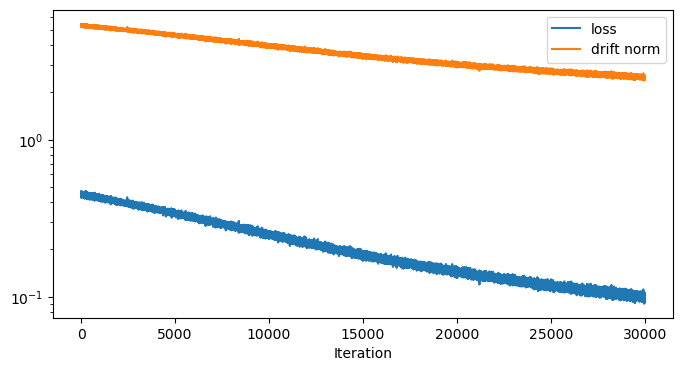

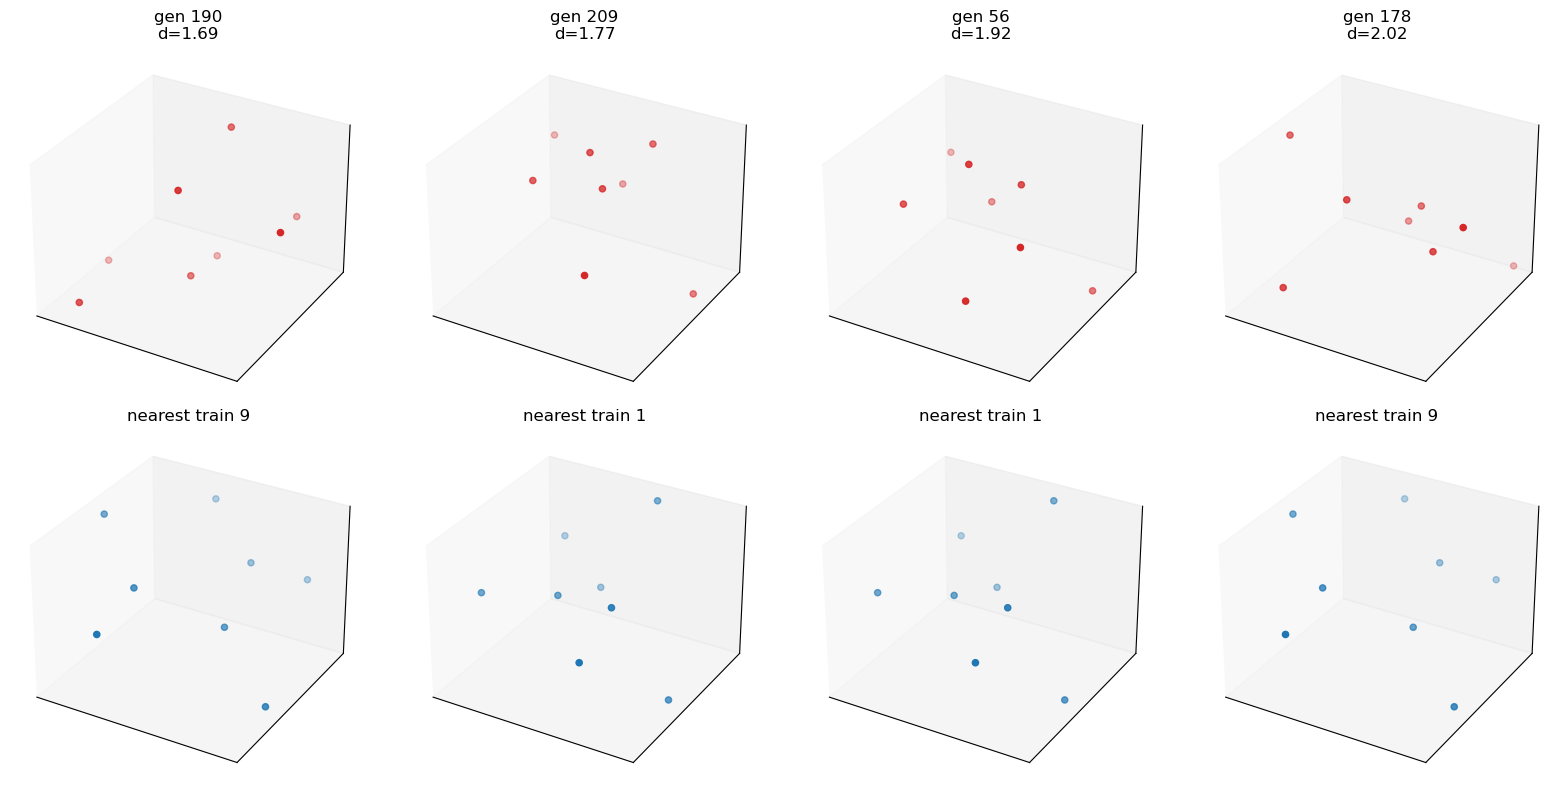

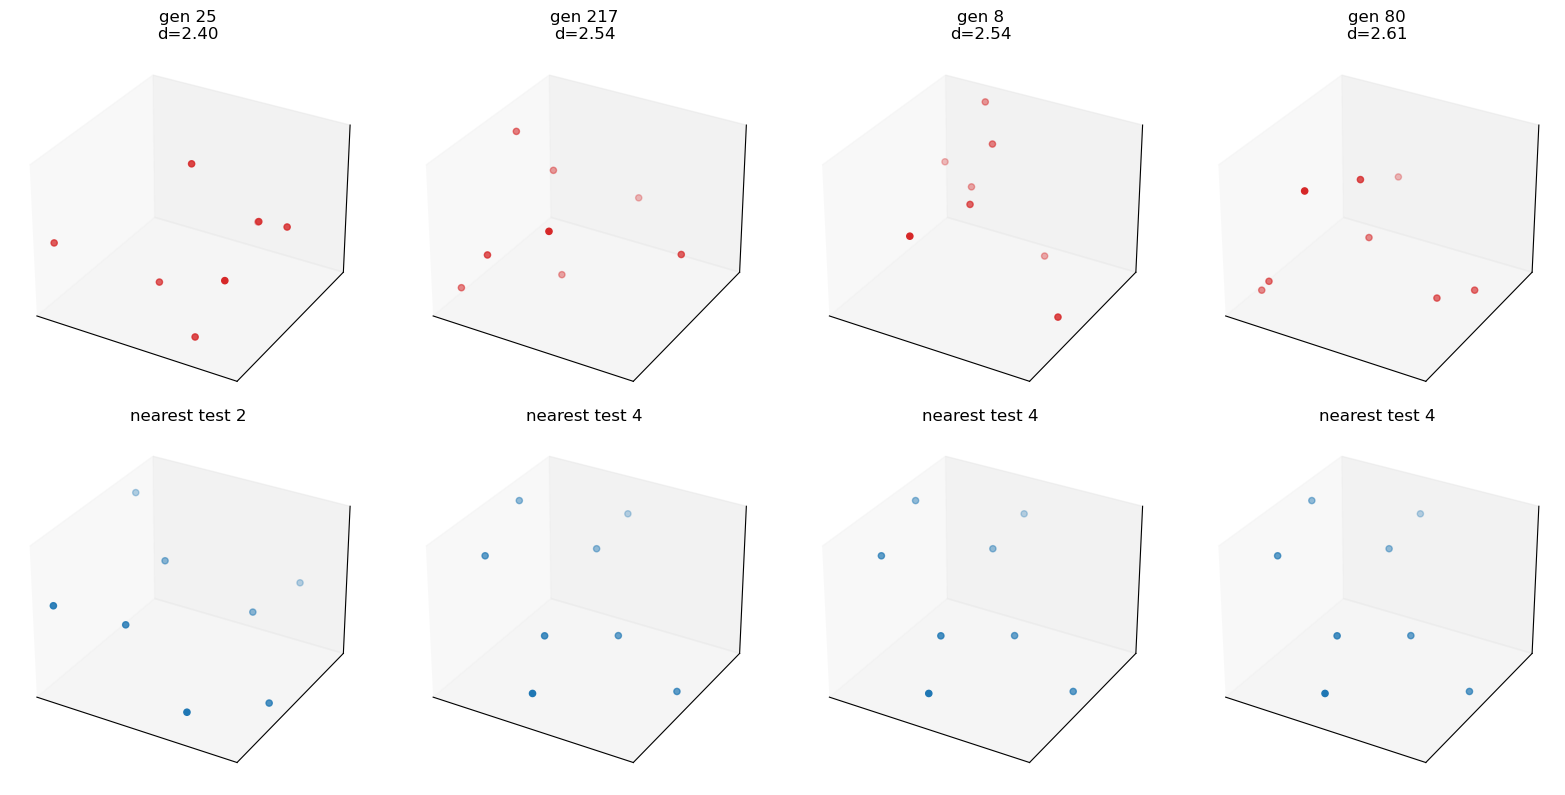

In [54]:
LONG_SIGMA = choose_sigma_for_long_run(globals().get("sweep_results", []), fallback=10.0)
LONG_NUM_ITERS = 30000
LONG_N_GEN_MOLS = 128
LONG_N_EVAL_MOLS = 256
LONG_LR = SWEEP_LR

print(f"Training long run with sigma={LONG_SIGMA}, num_iters={LONG_NUM_ITERS}")
long_result = train_one_bandwidth(
    sigma=LONG_SIGMA,
    data=sweep_data,
    num_iters=LONG_NUM_ITERS,
    n_gen_mols=LONG_N_GEN_MOLS,
    n_eval_mols=LONG_N_EVAL_MOLS,
    num_atoms=SWEEP_NUM_ATOMS,
    num_atom_types=SWEEP_NUM_ATOM_TYPES,
    lr=LONG_LR,
    log_every=2500,
)

long_eval = evaluate_generated_batch(
    long_result["model"],
    sweep_data,
    n_eval_mols=LONG_N_EVAL_MOLS,
    num_atoms=SWEEP_NUM_ATOMS,
    num_atom_types=SWEEP_NUM_ATOM_TYPES,
)

print_long_run_summary(long_result, long_eval)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(long_result["losses"], label="loss")
ax.plot(long_result["drift_norms"], label="drift norm")
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.legend()
display(fig)
plt.close(fig)

plot_nearest_generated(long_eval, sweep_data, SWEEP_NUM_ATOMS, k=4, split="train")
plot_nearest_generated(long_eval, sweep_data, SWEEP_NUM_ATOMS, k=4, split="test")


# Chemically Meaningful Atom-Type Setup

The previous sections emit unconstrained atom-type vectors and only apply `argmax` after training. This section constrains atom types to probabilities during training, samples type noise from a Dirichlet prior, and separates position/type drift weights.

In [55]:
try:
    from model.sample_prior import sample_atom_dirichlet_noise
except ImportError:
    sample_atom_dirichlet_noise = None


def sample_prob_type_noise(n_mols: int, num_atoms: int, num_atom_types: int):
    total_nodes = n_mols * num_atoms
    if sample_atom_dirichlet_noise is not None:
        return sample_atom_dirichlet_noise(total_nodes, num_atom_types)[0]
    alpha = torch.ones(num_atom_types)
    return torch.distributions.Dirichlet(alpha).sample((total_nodes,))


def sample_chemical_noise(n_mols: int, num_atoms: int, num_atom_types: int):
    pos_noise = sample_pos_noise(n_mols, num_atoms)
    type_noise = sample_prob_type_noise(n_mols, num_atoms, num_atom_types)
    return torch.cat([pos_noise, type_noise], dim=1).view(n_mols, -1)


def split_generated_prob_types(
    gen_mol: torch.Tensor,
    n_mols: int,
    num_atoms: int,
    num_atom_types: int,
    temperature: float = 1.0,
):
    flat = gen_mol.view(n_mols * num_atoms, -1)
    gen_pos, gen_type_logits = flat.split([3, num_atom_types], dim=1)
    gen_type_probs = torch.softmax(gen_type_logits / temperature, dim=1)
    return gen_pos, gen_type_logits, gen_type_probs


def type_entropy(type_probs: torch.Tensor, eps: float = 1e-8):
    return -(type_probs * type_probs.clamp_min(eps).log()).sum(dim=1).mean()


def evaluate_chemical_model(model, data, n_eval_mols, num_atoms, num_atom_types, temperature=1.0):
    model.eval()
    with torch.no_grad():
        noise = sample_chemical_noise(n_eval_mols, num_atoms, num_atom_types)
        gen_mol = model(noise)
        gen_pos, gen_type_logits, gen_type_probs = split_generated_prob_types(
            gen_mol, n_eval_mols, num_atoms, num_atom_types, temperature=temperature
        )
        gen_pos_flat = gen_pos.reshape(n_eval_mols, -1)
        train_dist = torch.cdist(gen_pos_flat, data["train_pos"])
        test_dist = torch.cdist(gen_pos_flat, data["test_pos"])
        gen_dist = torch.cdist(gen_pos_flat, gen_pos_flat)
        off_diag = ~torch.eye(n_eval_mols, dtype=torch.bool)

        atom_type_idx = gen_type_probs.argmax(dim=1).detach().cpu().long()
        batch_vec = torch.arange(n_eval_mols).repeat_interleave(num_atoms)
        pos_angstrom = gen_pos.detach().cpu() * data["pos_scale"].cpu()

        atom_stable, mol_stable = batch_to_stability(pos_angstrom, atom_type_idx, batch_vec)
        validity = batch_to_validity(pos_angstrom, atom_type_idx, batch_vec)
        valid_ids = [identifier for is_valid, identifier in validity if is_valid and identifier]
        type_hist = torch.bincount(atom_type_idx, minlength=num_atom_types).float()
        type_hist = type_hist / type_hist.sum().clamp_min(1.0)

    return {
        "nearest_train": train_dist.min(dim=1).values.mean().item(),
        "nearest_test": test_dist.min(dim=1).values.mean().item(),
        "gen_diversity": gen_dist[off_diag].mean().item(),
        "atom_stable": atom_stable,
        "mol_stable": mol_stable,
        "valid": sum(is_valid for is_valid, _ in validity) / len(validity),
        "unique_valid": len(set(valid_ids)) / max(1, len(valid_ids)),
        "type_hist": type_hist.tolist(),
        "type_entropy": type_entropy(gen_type_probs).item(),
        "gen_pos": gen_pos,
        "gen_type_probs": gen_type_probs,
    }


def train_chemical_drift(
    data,
    num_iters: int,
    n_gen_mols: int,
    n_eval_mols: int,
    num_atoms: int,
    num_atom_types: int,
    sigma_pos: float,
    sigma_type: float,
    lr: float,
    lambda_pos: float = 1.0,
    lambda_type: float = 1.0,
    entropy_weight: float = 0.0,
    temperature: float = 1.0,
    log_every: int = 2500,
):
    model = DummyModel(num_nodes=num_atoms, num_atom_types=num_atom_types)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses, pos_losses, type_losses, entropy_vals = [], [], [], []
    drift_norms = []
    start = time.time()

    for step in range(num_iters):
        optimizer.zero_grad()
        noise = sample_chemical_noise(n_gen_mols, num_atoms, num_atom_types)
        gen_mol = model(noise)
        gen_pos, gen_type_logits, gen_type_probs = split_generated_prob_types(
            gen_mol, n_gen_mols, num_atoms, num_atom_types, temperature=temperature
        )

        gen_pos_flat = gen_pos.reshape(n_gen_mols, -1)
        gen_type_flat = gen_type_probs.reshape(n_gen_mols, -1)

        V_pos = compute_drifting_field(gen_pos_flat, data["train_pos"], sigma=sigma_pos)
        V_type = compute_drifting_field(gen_type_flat, data["train_types"], sigma=sigma_type)

        loss_pos = (V_pos.pow(2).mean())
        loss_type = (V_type.pow(2).mean())
        entropy = type_entropy(gen_type_probs)
        loss = lambda_pos * loss_pos + lambda_type * loss_type + entropy_weight * entropy
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pos_losses.append(loss_pos.item())
        type_losses.append(loss_type.item())
        entropy_vals.append(entropy.item())
        drift_norms.append((V_pos.norm(dim=1).mean() + V_type.norm(dim=1).mean()).item())

        if (step + 1) % log_every == 0:
            print(
                f"iter={step + 1:<6} loss={loss.item():.5f} "
                f"pos={loss_pos.item():.5f} type={loss_type.item():.5f} entropy={entropy.item():.3f}"
            )

    metrics = evaluate_chemical_model(
        model, data, n_eval_mols, num_atoms, num_atom_types, temperature=temperature
    )
    metrics.update({
        "sigma": sigma_pos,
        "sigma_type": sigma_type,
        "final_loss": losses[-1],
        "min_loss": min(losses),
        "final_drift": drift_norms[-1],
        "max_drift": max(drift_norms),
        "seconds": time.time() - start,
        "losses": losses,
        "pos_losses": pos_losses,
        "type_losses": type_losses,
        "entropy_vals": entropy_vals,
        "drift_norms": drift_norms,
        "model": model,
    })
    return metrics


def print_chemical_summary(result):
    print(
        f"loss={result['final_loss']:.5f} drift={result['final_drift']:.4f} "
        f"div={result['gen_diversity']:.4f} nn_train={result['nearest_train']:.4f} "
        f"nn_test={result['nearest_test']:.4f} atom_st={result['atom_stable']:.3f} "
        f"mol_st={result['mol_stable']:.3f} valid={result['valid']:.3f} "
        f"uniq={result['unique_valid']:.3f} entropy={result['type_entropy']:.3f} "
        f"sec={result['seconds']:.1f}"
    )
    print("type_hist:", [round(x, 3) for x in result["type_hist"]])


iter=2500   loss=0.01112 pos=0.00561 type=0.00008 entropy=0.509
iter=5000   loss=0.01052 pos=0.00558 type=0.00006 entropy=0.462
iter=7500   loss=0.01030 pos=0.00555 type=0.00006 entropy=0.445
iter=10000  loss=0.01068 pos=0.00555 type=0.00015 entropy=0.440
iter=12500  loss=0.01023 pos=0.00556 type=0.00007 entropy=0.434
iter=15000  loss=0.01033 pos=0.00557 type=0.00007 entropy=0.440
iter=17500  loss=0.01039 pos=0.00555 type=0.00009 entropy=0.440
iter=20000  loss=0.01035 pos=0.00555 type=0.00010 entropy=0.430
iter=22500  loss=0.01022 pos=0.00554 type=0.00008 entropy=0.430
iter=25000  loss=0.01041 pos=0.00555 type=0.00011 entropy=0.433
iter=27500  loss=0.01025 pos=0.00554 type=0.00007 entropy=0.437
iter=30000  loss=0.01022 pos=0.00554 type=0.00006 entropy=0.436
loss=0.01022 drift=0.4105 div=0.0703 nn_train=3.3789 nn_test=4.0731 atom_st=0.126 mol_st=0.000 valid=0.000 uniq=0.000 entropy=0.435 sec=99.6
type_hist: [0.376, 0.435, 0.144, 0.045, 0.0]


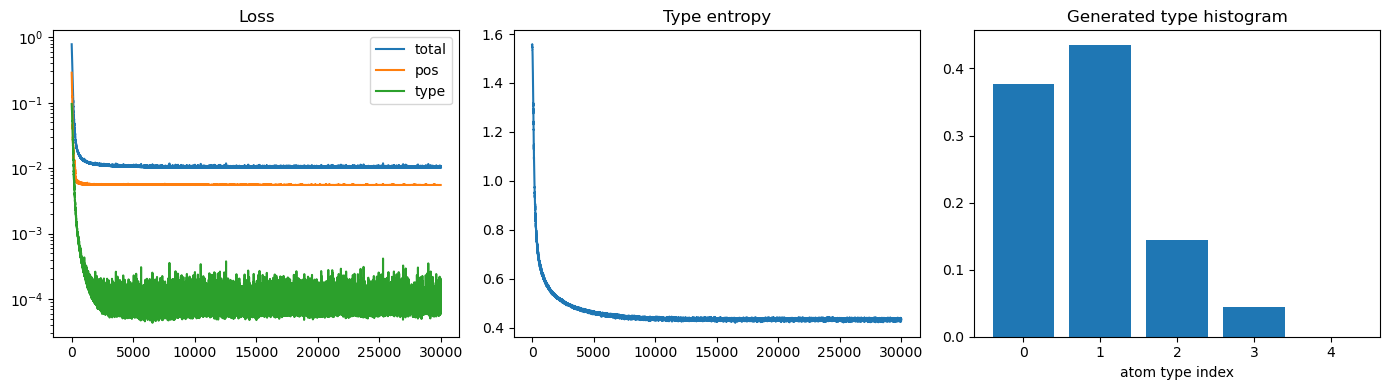

In [56]:
CHEM_NUM_ITERS = 30000
CHEM_N_GEN_MOLS = 128
CHEM_N_EVAL_MOLS = 256
CHEM_SIGMA_POS = 1.0
CHEM_SIGMA_TYPE = 1.0
CHEM_LR = 0.001
CHEM_LAMBDA_POS = 1.0
CHEM_LAMBDA_TYPE = 5.0
CHEM_ENTROPY_WEIGHT = 0.01
CHEM_TEMPERATURE = 1.0

chemical_result = train_chemical_drift(
    data=sweep_data,
    num_iters=CHEM_NUM_ITERS,
    n_gen_mols=CHEM_N_GEN_MOLS,
    n_eval_mols=CHEM_N_EVAL_MOLS,
    num_atoms=SWEEP_NUM_ATOMS,
    num_atom_types=SWEEP_NUM_ATOM_TYPES,
    sigma_pos=CHEM_SIGMA_POS,
    sigma_type=CHEM_SIGMA_TYPE,
    lr=CHEM_LR,
    lambda_pos=CHEM_LAMBDA_POS,
    lambda_type=CHEM_LAMBDA_TYPE,
    entropy_weight=CHEM_ENTROPY_WEIGHT,
    temperature=CHEM_TEMPERATURE,
    log_every=2500,
)

print_chemical_summary(chemical_result)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(chemical_result["losses"], label="total")
axes[0].plot(chemical_result["pos_losses"], label="pos")
axes[0].plot(chemical_result["type_losses"], label="type")
axes[0].set_yscale("log")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(chemical_result["entropy_vals"])
axes[1].set_title("Type entropy")

axes[2].bar(range(SWEEP_NUM_ATOM_TYPES), chemical_result["type_hist"])
axes[2].set_title("Generated type histogram")
axes[2].set_xlabel("atom type index")
fig.tight_layout()
display(fig)
plt.close(fig)
